# 출시 전 LLM 리뷰 분석 보고서: Action 장르

## 분석 목적

이 보고서는 `Action` 장르와 유사한 Steam 인디게임의 출시 초기 리뷰를 LLM으로 분석하여, 개발자가 출시 전 단계에서 **유저들이 어떤 요소를 긍정적으로 평가하고, 어떤 요소에 불만을 가지는지** 파악하는 것을 목적으로 한다.

이번 보고서에서는 **v2 결과**를 최종 기준으로 사용한다.  
리뷰 수를 더 늘린 v3 결과도 있었지만, 일부 게임의 비중이 커지는 문제가 있어 장르 단위 분석에는 v2가 더 적합하다고 판단하였다.

## 핵심 질문

1. Action 장르 유저들은 어떤 요소를 긍정적으로 평가하는가?
2. Action 장르 유저들은 어떤 요소에 불만을 가지는가?
3. 가격대, Steam 태그, 플레이 방식에 따라 이슈가 달라지는가?
4. 출시 전 단계에서 우선적으로 점검해야 할 리스크는 무엇인가?
5. 이 결과를 출시 전 체크리스트와 개발 우선순위로 어떻게 연결할 수 있는가?

# 1. 설정값

아래 설정값은 `03-1_run_llm_sentiment_Action_PreLaunch_v2.ipynb`에서 생성한 LLM 분석 결과를 불러오기 위한 경로 설정이다.

다른 환경에서 실행할 경우 `ROOT`만 본인 프로젝트 경로에 맞게 수정하면 된다.

| 항목 | 설정값 |
|---|---|
| 분석 장르 | Action |
| 리뷰 구간 | D0-D30 |
| 게임당 최대 리뷰 수 | 100개 |
| 전체 최대 리뷰 수 | 5,000개 |
| 샘플링 방식 | `balanced_by_steam_label` |
| 최종 기준 | v2 결과 |

In [1]:
# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import platform
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [2]:
# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정합니다.
ROOT = Path("C:/Users/joon5/Documents/github/steam-indie-game-analysis")

# ============================================================
# LLM 분석 산출물 폴더
# ============================================================
RUN_NAME = "main_action_d0-d30_1000_v2"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 보고서에 표시할 LLM 실행 설정값
TARGET_GENRE = "Action"
REVIEWS_PER_GAME = 100
MAX_TOTAL_REVIEWS = 5000
SAMPLE_MODE = "balanced_by_steam_label"

# LLM 분석 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"

# 전처리 산출물
PREPROCESS_RUN_NAME = "preprocess_llm"
PREPROCESS_OUTPUT_DIR = ROOT / "data" / "outputs" / PREPROCESS_RUN_NAME
PREPROCESSED_REVIEWS_PATH = PREPROCESS_OUTPUT_DIR / "llm_preprocessed_reviews.csv"

# 선택 산출물
GAME_SUMMARY_PATH = OUTPUT_DIR / "llm_game_summary.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"

print("프로젝트 루트:", ROOT)
print("LLM 분석 결과:", RESULT_CSV_PATH)
print("이슈 태그 결과:", ISSUE_TAG_FLAT_PATH)
print("전처리 리뷰 파일:", PREPROCESSED_REVIEWS_PATH)

프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
LLM 분석 결과: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_review_analysis_result.csv
이슈 태그 결과: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_issue_tags_flat.csv
전처리 리뷰 파일: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\preprocess_llm\llm_preprocessed_reviews.csv


# 2. 데이터 불러오기

이 보고서에서 사용하는 데이터는 세 가지다.

| 데이터 | 역할 |
|---|---|
| `df_result` | 리뷰 1개 단위의 LLM 분석 결과 |
| `df_tag` | 리뷰에서 추출된 이슈 태그 단위 결과 |
| `df_META` | 가격대, Steam 태그, 플레이 방식 등 게임 메타데이터 |

In [3]:
# ============================================================
# 데이터 불러오기
# ============================================================
# LLM 분석 결과와 이슈 태그 결과를 불러온다.
# df_META는 가격대/태그/플레이 방식 분석에 사용한다.

df_result = pd.read_csv(RESULT_CSV_PATH)
df_tag = pd.read_csv(ISSUE_TAG_FLAT_PATH)
df_META = pd.read_csv(PREPROCESSED_REVIEWS_PATH)

print("LLM 분석 결과 행 수:", len(df_result))
print("이슈 태그 행 수:", len(df_tag))
print("분석 게임 수:", df_result["appid"].nunique())

display(df_result.head())
display(df_tag.head())

LLM 분석 결과 행 수: 770
이슈 태그 행 수: 1552
분석 게임 수: 28


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,193552472,1054510,Survivalist: Invisible Strain,2025-04-25 13:52:54,2025-04-25,0.0,D0-D30,positive,63.216667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'Definitely worth the price. Its a quite uniqu...",low,가격 대비 가치가 높고 독창적인 게임성을 가진 훌륭한 게임임.,"현재의 독창적인 게임성을 유지하며, 향후 업데이트에서도 가격 대비 만족도를 높일 수 있는 콘텐츠를 지속적으로 추가하십시오.",exact_match
1,success,193564502,1054510,Survivalist: Invisible Strain,2025-04-25 17:00:16,2025-04-25,0.0,D0-D30,positive,1006.266667,8.0,0.543334,positive,5.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'positive', 'evidence': 'recruit NPCs to your community and have them do...",low,"NPC 관리 시스템과 좀비 감염 메커니즘이 뛰어나며, 다수 좀비와의 전투 밸런스 조정이 필요함.",NPC 관리 및 좀비 감염 시스템에 대한 유저 만족도가 높음. 다수 좀비와의 전투 밸런스를 검토하여 난이도 조절을 고려하십시오.,exact_match
2,success,193570077,1054510,Survivalist: Invisible Strain,2025-04-25 18:29:43,2025-04-25,0.0,D0-D30,positive,71.483333,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'game I can get lost in for hours'}, {'categor...",low,전략적 깊이가 있고 도전적인 난이도를 가진 몰입감 높은 게임임.,"높은 난이도와 전략적 깊이를 선호하는 유저층이 형성되어 있으므로, 현재의 도전적인 난이도 기조를 유지하십시오.",exact_match
3,success,193578442,1054510,Survivalist: Invisible Strain,2025-04-25 20:45:58,2025-04-25,0.0,D0-D30,positive,5.733333,0.0,0.478548,mixed,4.0,multiplayer_network,"[{'category': 'multiplayer_network', 'sentiment': 'negative', 'evidence': 'only one conversation going at a time, fr...",high,"게임 자체는 매우 훌륭하고 자유도가 높으나, 멀티플레이 시 한 번에 하나의 대화만 가능한 시스템이 협동 플레이를 저해함.","멀티플레이어 환경에서 NPC와의 대화 시스템을 독립적으로 처리할 수 있도록 개선하여, 여러 플레이어가 동시에 각기 다른 NPC와 대화할 수 있는 환경을 구축하세요.",partial_match
4,success,193594348,1054510,Survivalist: Invisible Strain,2025-04-26 02:06:16,2025-04-25,1.0,D0-D30,positive,241.783333,8.0,0.563492,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'best example of a labor of love, fun, hard, a...",low,"전작부터 발전해온 모습이 인상적이며, 장르적 특성을 잘 살린 완성도 높은 게임임.","현재의 게임 방향성을 유지하며, 기존 팬들이 만족하는 깊이 있는 게임플레이 요소를 지속적으로 업데이트하세요.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,193552472,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,63.216667,0.0,0.500000,positive_praise,긍정 칭찬,positive,Definitely worth the price. Its a quite unique game
1,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,recruit NPCs to your community and have them do all the tedious stuff
2,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,infect your opponents with the zombie virus
3,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,balance,밸런스,neutral,Combat against zombies can be dicey when faced against multiple opponents
4,193570077,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,71.483333,0.0,0.500000,positive_praise,긍정 칭찬,positive,game I can get lost in for hours


## 2-1. 메타데이터 결합

가격대별, Steam 태그별, 플레이 방식별 분석을 하기 위해 LLM 결과에 게임 메타데이터를 붙인다.

이 단계는 LLM 분석을 새로 실행하는 것이 아니다.  
이미 만들어진 LLM 결과에 `price_group`, `top_steam_tags_text`, `categories_text`를 붙여서 비교 분석이 가능하도록 만드는 단계다.

In [4]:
# ============================================================
# 2-1. 메타데이터 준비
# ============================================================
# df_META에서 추가 분석에 필요한 컬럼만 가져온다.
# appid 기준으로 게임 1개당 1행만 남긴다.

meta_cols = [
    "appid",
    "price",
    "price_group",
    "top_steam_tags_text",
    "categories_text",
]

df_meta = df_META[meta_cols].copy()
df_meta = df_meta.drop_duplicates("appid")

print("메타데이터 행 수:", len(df_meta))
display(df_meta.head())

메타데이터 행 수: 188


,appid,price,price_group,top_steam_tags_text,categories_text
0,324470,3.99,0-5,"Indie, Racing, Early Access, Parkour, First-Person","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P..."
151,571740,4.49,0-5,"Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement..."
21261,603390,29.99,20-40,"RPG, Adventure, Casual, Indie, Programming, Retro, Idler, Logic, Text-Based, Great Soundtrack","Single-player, Steam Achievements, Camera Comfort, Color Alternatives, Custom Volume Controls, Adjustable Difficulty..."
22138,638990,19.99,10-20,"Story Rich, Multiple Endings, Action RPG, Survival, Adventure, Zombies, Female Protagonist, Post-apocalyptic, Crafti...","Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing"
23795,695330,14.99,10-20,"Open World, Mystery, Visual Novel, Narrative, Female Protagonist, Emotional, Interactive Fiction, Exploration, Atmos...","Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing"


In [5]:
# ============================================================
# 2-2. LLM 분석 결과에 메타데이터 결합
# ============================================================
# appid 기준으로 df_result와 df_tag에 메타데이터를 붙인다.

merge_cols = [
    "price",
    "price_group",
    "top_steam_tags_text",
    "categories_text",
]

# 같은 컬럼이 이미 있으면 삭제하고 다시 붙인다.
df_result = df_result.drop(columns=merge_cols, errors="ignore")
df_tag = df_tag.drop(columns=merge_cols, errors="ignore")

df_result = df_result.merge(df_meta, on="appid", how="left")
df_tag = df_tag.merge(df_meta, on="appid", how="left")

print("df_result 행 수:", len(df_result))
print("df_tag 행 수:", len(df_tag))

display(
    df_result[[
        "appid",
        "game_name",
        "price",
        "price_group",
        "top_steam_tags_text",
        "categories_text",
    ]].head()
)

df_result 행 수: 770
df_tag 행 수: 1552


,appid,game_name,price,price_group,top_steam_tags_text,categories_text
0,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."
1,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."
2,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."
3,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."
4,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."


In [6]:
# ============================================================
# 2-3. 플레이 방식 분류
# ============================================================
# categories_text를 보고 싱글/멀티/협동 여부를 단순 분류한다.
# 협동(Co-op)이 있으면 협동 포함으로 먼저 분류한다.

def classify_play_mode(categories_text):
    text = str(categories_text).lower()

    has_single = "single-player" in text
    has_multi = "multi-player" in text or "multiplayer" in text
    has_coop = "co-op" in text or "cooperative" in text

    if has_coop:
        return "협동 포함"
    if has_multi:
        return "멀티 포함"
    if has_single:
        return "싱글 중심"
    return "기타/미확인"


df_result["play_mode_group"] = df_result["categories_text"].apply(classify_play_mode)
df_tag["play_mode_group"] = df_tag["categories_text"].apply(classify_play_mode)

print("[플레이 방식 분포]")
display(df_result["play_mode_group"].value_counts())

[플레이 방식 분포]


play_mode_group
싱글 중심    593
협동 포함    175
멀티 포함      2
Name: count, dtype: int64

In [7]:
# ============================================================
# 2-4. Steam 태그 펼치기
# ============================================================
# top_steam_tags_text는 여러 태그가 문자열로 들어 있다.
# 태그별 분석을 위해 하나의 태그가 한 행이 되도록 펼친다.

def split_steam_tags(tag_text):
    if pd.isna(tag_text):
        return []

    text = str(tag_text)
    text = text.replace("[", "").replace("]", "")
    text = text.replace("'", "").replace('"', "")

    tag_list = [tag.strip() for tag in text.split(",")]
    tag_list = [tag for tag in tag_list if tag != ""]
    return tag_list


df_tag_for_steam_tag = df_tag.copy()
df_tag_for_steam_tag["steam_tag"] = df_tag_for_steam_tag["top_steam_tags_text"].apply(split_steam_tags)
df_tag_for_steam_tag = df_tag_for_steam_tag.explode("steam_tag")
df_tag_for_steam_tag = df_tag_for_steam_tag.dropna(subset=["steam_tag"])

print("Steam 태그 펼친 후 행 수:", len(df_tag_for_steam_tag))
print("[상위 Steam 태그]")
display(df_tag_for_steam_tag["steam_tag"].value_counts().head(20))

Steam 태그 펼친 후 행 수: 15520
[상위 Steam 태그]


steam_tag
Action                     752
First-Person               707
Exploration                672
RPG                        629
Open World                 593
Action RPG                 519
Character Customization    518
2D                         516
Singleplayer               416
3D                         392
Puzzle                     349
Controller                 323
Action Roguelike           319
Horror                     316
Third Person               305
Rogue-lite                 304
Bullet Hell                302
Pixel Graphics             273
Choices Matter             271
Adventure                  248
Name: count, dtype: int64

In [8]:
# ============================================================
# 2-5. 분석 공통 설정
# ============================================================
# 여러 분석에서 반복해서 사용하는 기준값을 한 곳에 모아둔다.

issue_col = "issue_name_kor" if "issue_name_kor" in df_tag.columns else "tag_category"
price_group_order = ["0-5", "5-10", "10-20", "20-40", "40+"]
play_mode_order = ["싱글 중심", "멀티 포함", "협동 포함", "기타/미확인"]
positive_exclude_keywords = ["긍정 칭찬", "positive_praise", "positive praise", "praise"]

print("이슈명 컬럼:", issue_col)

이슈명 컬럼: issue_name_kor


# 3. 데이터 품질 점검 요약

In [9]:
# ============================================================
# 3. 데이터 품질 점검 요약
# ============================================================
# 보고서에 사용하기 전에 기본 품질을 확인한다.

reviews_without_tags = set(df_result["recommendationid"]) - set(df_tag["recommendationid"])

quality_summary = pd.DataFrame({
    "점검 항목": [
        "분석 결과 행 수",
        "분석 게임 수",
        "분석 성공 수",
        "중복 리뷰 ID 수",
        "리뷰 기간",
        "출시 후 경과일 범위",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["analysis_status"] == "success").sum(),
        df_result["recommendationid"].duplicated().sum(),
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{df_result['days_from_release'].min():.0f} ~ {df_result['days_from_release'].max():.0f}",
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        len(reviews_without_tags),
    ]
})

display(quality_summary)

,점검 항목,값
0,분석 결과 행 수,770
1,분석 게임 수,28
2,분석 성공 수,770
3,중복 리뷰 ID 수,0
4,리뷰 기간,D0-D30
5,출시 후 경과일 범위,0 ~ 30
6,Steam 긍정 리뷰 수,511
7,Steam 부정 리뷰 수,259
8,이슈 태그 없는 리뷰 수,0


## 결과 설명

품질 점검표는 이번 분석 결과가 보고서에 사용할 수 있는지 확인하는 단계다.  
분석 성공 수가 전체 리뷰 수와 같고, 중복 리뷰가 없으며, 출시 후 경과일이 D0-D30 안에 있으면 기본 조건은 충족했다고 볼 수 있다.

다만 표본은 전체 Steam 시장이 아니라 LLM 분석 대상으로 선별된 리뷰이므로, 결과는 절대적인 시장 수치가 아니라 **표본 내 경향**으로 해석해야 한다.

# 4. 출시 전 분석 대상 요약

In [10]:
# ============================================================
# 4. 출시 전 분석 대상 요약
# ============================================================
# 이번 보고서의 분석 조건을 표로 정리한다.

basic_summary = pd.DataFrame({
    "항목": [
        "분석 관점",
        "분석 대상",
        "리뷰 구간",
        "게임당 최대 리뷰 수",
        "전체 최대 리뷰 수",
        "샘플링 방식",
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 분석 성공률",
    ],
    "내용": [
        "출시 전 분석",
        "Action 장르 유사 게임들의 출시 초기 리뷰",
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{REVIEWS_PER_GAME:,}개",
        f"{MAX_TOTAL_REVIEWS:,}개",
        SAMPLE_MODE,
        f"{len(df_result):,}개",
        f"{df_result['appid'].nunique():,}개",
        f"{(df_result['steam_label_text'] == 'positive').sum():,}개",
        f"{(df_result['steam_label_text'] == 'negative').sum():,}개",
        f"{(df_result['analysis_status'] == 'success').mean() * 100:.1f}%",
    ]
})

display(basic_summary)

,항목,내용
0,분석 관점,출시 전 분석
1,분석 대상,Action 장르 유사 게임들의 출시 초기 리뷰
2,리뷰 구간,D0-D30
3,게임당 최대 리뷰 수,100개
4,전체 최대 리뷰 수,"5,000개"
5,샘플링 방식,balanced_by_steam_label
6,최종 분석 리뷰 수,770개
7,최종 분석 게임 수,28개
8,Steam 긍정 리뷰 수,511개
9,Steam 부정 리뷰 수,259개


---
---
---

# 5. 전체 LLM 감정 분석 결과

## 이 분석을 하는 이유

Steam 라벨은 유저가 추천했는지 여부를 보여준다.  
반면 LLM 감정은 리뷰 본문을 읽고 긍정, 부정, 혼합, 중립을 더 세부적으로 구분한다.

## 한줄 결과 설명

전체 감정 분포를 통해 Action 장르 출시 초기 리뷰의 전반적인 분위기를 확인한다.

In [11]:
# ============================================================
# 5. 전체 LLM 감정 분석 결과
# ============================================================
# Steam 라벨과 LLM 감정 분포를 각각 확인한다.

steam_label_summary = (
    df_result["steam_label_text"]
    .value_counts()
    .rename_axis("Steam 라벨")
    .reset_index(name="리뷰 수")
)
steam_label_summary["비율(%)"] = (steam_label_summary["리뷰 수"] / len(df_result) * 100).round(1)

llm_sentiment_summary = (
    df_result["llm_sentiment"]
    .value_counts()
    .rename_axis("LLM 감정")
    .reset_index(name="리뷰 수")
)
llm_sentiment_summary["비율(%)"] = (llm_sentiment_summary["리뷰 수"] / len(df_result) * 100).round(1)

print("[Steam 라벨 분포]")
display(steam_label_summary)

print("[LLM 감정 분포]")
display(llm_sentiment_summary)

[Steam 라벨 분포]


,Steam 라벨,리뷰 수,비율(%)
0,positive,511,66.4
1,negative,259,33.6


[LLM 감정 분포]


,LLM 감정,리뷰 수,비율(%)
0,positive,465,60.4
1,negative,241,31.3
2,mixed,58,7.5
3,neutral,6,0.8


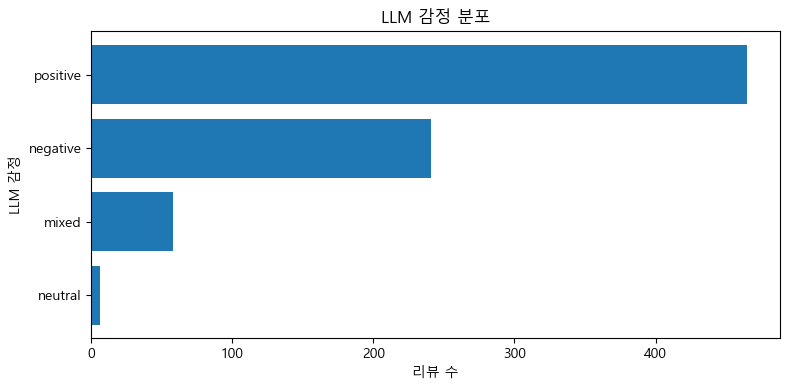

In [12]:
# ============================================================
# 5-1. LLM 감정 분포 그래프
# ============================================================
# 감정별 리뷰 수를 막대그래프로 확인한다.

plot_df = llm_sentiment_summary.sort_values("리뷰 수", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["LLM 감정"], plot_df["리뷰 수"])
plt.title("LLM 감정 분포")
plt.xlabel("리뷰 수")
plt.ylabel("LLM 감정")
plt.tight_layout()
plt.show()

## 결과 설명

전체 감정 분포는 분석 대상 리뷰가 긍정 중심인지, 부정 중심인지, 또는 혼합 반응이 많은지 확인하는 기준이다.  
출시 전 분석에서는 부정과 혼합 리뷰에 포함된 불편 요소를 확인해 체크리스트로 연결하는 것이 중요하다.

# 6. Steam 라벨과 LLM 감정 비교

## 이 분석을 하는 이유

Steam 추천/비추천 라벨과 LLM 감정 판단은 항상 같은 의미가 아니다.  
추천 리뷰 안에도 불만이 있을 수 있고, 비추천 리뷰 안에도 장점이 있을 수 있다.

## 한줄 결과 설명

Steam 라벨과 LLM 감정이 크게 어긋나지 않는지 확인해, LLM 결과를 보조 지표로 사용할 수 있는지 점검한다.

In [13]:
# ============================================================
# 6. Steam 라벨과 LLM 감정 비교
# ============================================================
# sentiment_relation은 Steam 라벨과 LLM 감정의 관계를 나타낸다.

sentiment_relation_summary = (
    df_result["sentiment_relation"]
    .value_counts()
    .rename_axis("관계")
    .reset_index(name="리뷰 수")
)
sentiment_relation_summary["비율(%)"] = (sentiment_relation_summary["리뷰 수"] / len(df_result) * 100).round(1)

display(sentiment_relation_summary)

sentiment_cross = pd.crosstab(
    df_result["steam_label_text"],
    df_result["llm_sentiment"],
    margins=True
)

display(sentiment_cross)

,관계,리뷰 수,비율(%)
0,exact_match,704,91.4
1,partial_match,58,7.5
2,unclear,6,0.8
3,mismatch,2,0.3


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,19,239,1,0,259
positive,39,2,5,465,511
All,58,241,6,465,770


## 결과 설명

이 표는 Steam 라벨과 LLM 감정 판단이 얼마나 일치하는지 보여준다.  
`exact_match`와 `partial_match`가 대부분이라면 LLM 감정 결과를 리뷰 본문 해석용 보조 지표로 사용할 수 있다.

`partial_match`는 긍정 리뷰 안의 아쉬움, 부정 리뷰 안의 장점처럼 복합적인 반응을 볼 수 있는 지점이다.

# 7. 긍정 요소 분석

## 이 분석을 하는 이유

긍정 요소 분석은 유저가 어떤 점을 재미있거나 만족스럽게 느꼈는지 확인하기 위한 분석이다.

## 한줄 결과 설명

긍정 태그를 통해 Action 장르에서 유지하거나 강화해야 할 강점 후보를 확인한다.

In [14]:
# ============================================================
# 7. 긍정 요소 분석
# ============================================================
# 긍정 방향의 이슈 태그를 집계한다.

positive_issue_summary = (
    df_tag[df_tag["tag_sentiment"] == "positive"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        태그수=("recommendationid", "size"),
        영향리뷰수=("recommendationid", "nunique"),
        평균플레이시간=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["영향리뷰수", "태그수"], ascending=False)
)
positive_issue_summary["평균플레이시간"] = positive_issue_summary["평균플레이시간"].round(1)

display(positive_issue_summary.head(15))

,tag_category,issue_name_kor,태그수,영향리뷰수,평균플레이시간
11,positive_praise,긍정 칭찬,463,462,15.1
5,gameplay_loop,게임플레이 루프,65,64,43.4
6,graphics_audio,그래픽/사운드,37,37,7.4
4,difficulty,난이도,26,26,15.4
14,story,스토리,13,13,46.4
1,content_volume,콘텐츠 분량,12,12,12.3
12,price_value,가격/가치,12,12,10.9
3,developer_communication,개발사 소통,9,9,25.8
2,control,조작감,6,6,3.0
9,other,기타,5,5,11.0


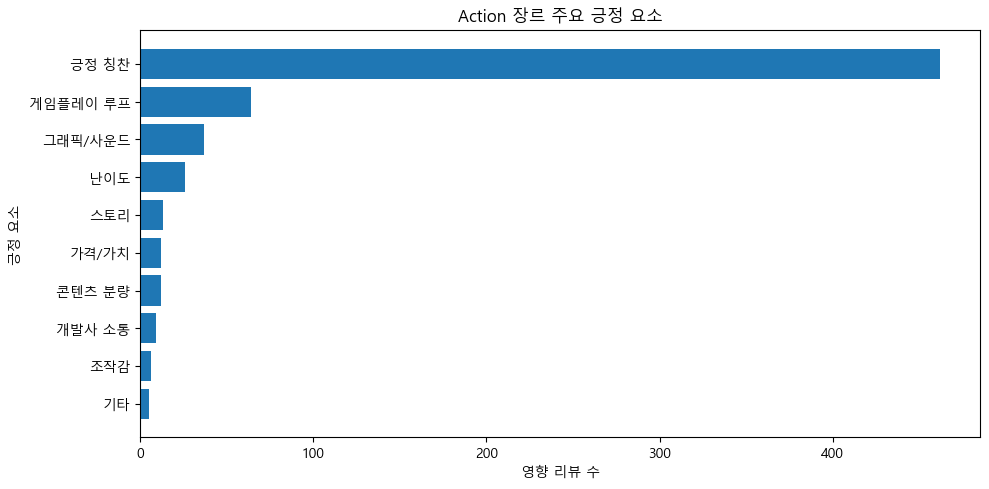

In [15]:
# ============================================================
# 7-1. 주요 긍정 요소 그래프
# ============================================================
# 영향 리뷰 수 기준 상위 긍정 요소를 시각화한다.

positive_plot_df = positive_issue_summary.head(10).sort_values("영향리뷰수", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(positive_plot_df["issue_name_kor"], positive_plot_df["영향리뷰수"])
plt.title("Action 장르 주요 긍정 요소")
plt.xlabel("영향 리뷰 수")
plt.ylabel("긍정 요소")
plt.tight_layout()
plt.show()

## 결과 설명

긍정 요소는 해당 장르에서 유저 만족을 만든 요소를 보여준다.  
단, `긍정 칭찬`은 “재밌다”, “추천한다”처럼 전반적인 만족 표현에 가깝다.

그래서 실제 개발 전략을 세울 때는 `긍정 칭찬` 자체보다, 게임플레이 루프, 그래픽/사운드, 난이도, 콘텐츠 분량, 가격/가치처럼 구체적인 강점 태그를 함께 보는 것이 좋다.

# 8. 부정 요소 분석

## 이 분석을 하는 이유

부정 요소 분석은 유저가 어떤 점에 불만을 느꼈는지 확인하기 위한 분석이다.

## 한줄 결과 설명

부정 태그를 통해 출시 전 단계에서 우선 점검해야 할 리스크 후보를 확인한다.

In [16]:
# ============================================================
# 8. 부정 요소 분석
# ============================================================
# 부정 방향의 이슈 태그를 집계한다.

negative_issue_summary = (
    df_tag[df_tag["tag_sentiment"] == "negative"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        태그수=("recommendationid", "size"),
        영향리뷰수=("recommendationid", "nunique"),
        평균플레이시간=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["영향리뷰수", "태그수"], ascending=False)
)
negative_issue_summary["평균플레이시간"] = negative_issue_summary["평균플레이시간"].round(1)

display(negative_issue_summary.head(15))

,tag_category,issue_name_kor,태그수,영향리뷰수,평균플레이시간
7,gameplay_loop,게임플레이 루프,156,149,10.3
1,bug,버그,92,89,17.1
3,control,조작감,68,68,12.0
0,balance,밸런스,63,57,17.8
6,difficulty,난이도,57,56,9.2
18,ui_ux,UI/UX,56,56,17.2
2,content_volume,콘텐츠 분량,37,37,22.9
8,graphics_audio,그래픽/사운드,37,36,10.5
16,story,스토리,33,33,19.1
11,other,기타,32,31,20.9


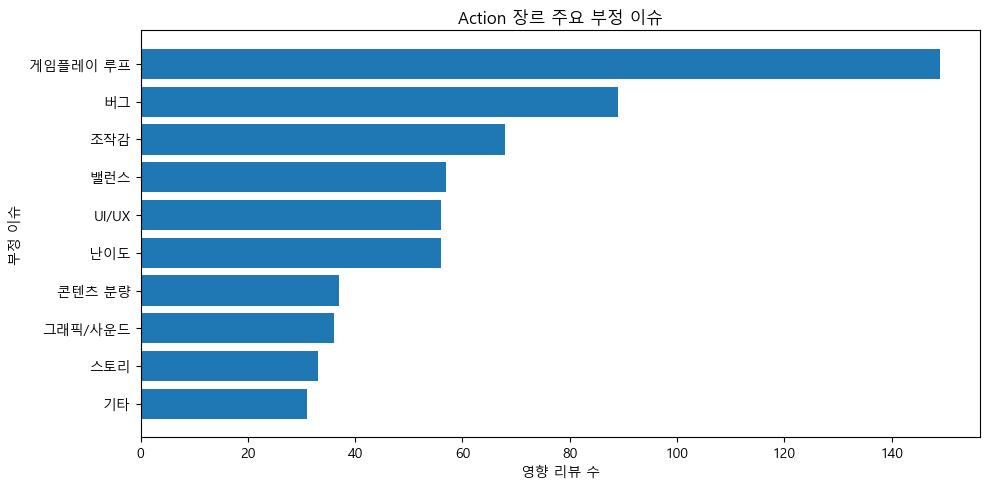

In [17]:
# ============================================================
# 8-1. 주요 부정 요소 그래프
# ============================================================
# 영향 리뷰 수 기준 상위 부정 요소를 시각화한다.

negative_plot_df = negative_issue_summary.head(10).sort_values("영향리뷰수", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(negative_plot_df["issue_name_kor"], negative_plot_df["영향리뷰수"])
plt.title("Action 장르 주요 부정 이슈")
plt.xlabel("영향 리뷰 수")
plt.ylabel("부정 이슈")
plt.tight_layout()
plt.show()

## 결과 설명

부정 요소는 출시 전 단계에서 미리 점검해야 할 리스크를 보여준다.  
특히 게임플레이 루프, 조작감, UI/UX, 밸런스, 난이도, 버그와 같은 요소는 출시 직후 유저가 바로 체감하는 문제로 이어질 수 있다.

# 9. 긍정과 부정이 함께 나타난 핵심 평가 축

## 이 분석을 하는 이유

어떤 이슈는 긍정과 부정 양쪽에서 모두 등장한다.  
이런 이슈는 잘 만들면 강점이 되고, 부족하면 리스크가 되는 핵심 평가 축으로 볼 수 있다.

## 한줄 결과 설명

긍정과 부정이 함께 나타난 이슈를 통해 Action 장르 유저 평가를 좌우하는 핵심 요소를 확인한다.

In [18]:
# ============================================================
# 9. 긍정과 부정이 함께 나타난 핵심 평가 축
# ============================================================
# 이슈별로 긍정/부정 태그가 얼마나 나왔는지 비교한다.

issue_sentiment_pivot = pd.crosstab(
    df_tag["issue_name_kor"],
    df_tag["tag_sentiment"]
)

for col in ["positive", "negative", "mixed", "neutral"]:
    if col not in issue_sentiment_pivot.columns:
        issue_sentiment_pivot[col] = 0

issue_sentiment_pivot["total"] = issue_sentiment_pivot[["positive", "negative", "mixed", "neutral"]].sum(axis=1)
issue_sentiment_pivot = issue_sentiment_pivot.sort_values("total", ascending=False)

both_side_issues = issue_sentiment_pivot[
    (issue_sentiment_pivot["positive"] > 0) &
    (issue_sentiment_pivot["negative"] > 0)
].copy()

display(both_side_issues.head(15))

tag_sentiment,mixed,negative,neutral,positive,total
issue_name_kor,,,,,
게임플레이 루프,8,156,18,65,247
난이도,1,57,14,26,98
그래픽/사운드,2,37,6,37,82
조작감,1,68,1,6,76
콘텐츠 분량,1,37,20,12,70
밸런스,1,63,2,1,67
UI/UX,0,56,4,4,64
기타,1,32,13,5,51
스토리,0,33,4,13,50


## 결과 설명

긍정과 부정이 함께 나타난 이슈는 단순한 장점이나 단점이 아니라, 장르 평가를 좌우하는 핵심 축이다.  
예를 들어 게임플레이 루프는 잘 설계되면 강점이 되지만, 반복성이 약하거나 보상이 부족하면 가장 큰 불만으로 이어질 수 있다.

# 10. 시급도 기준으로 본 출시 전 리스크

## 이 분석을 하는 이유

`urgency`는 LLM이 리뷰 본문을 읽고 해당 문제가 얼마나 시급하게 개선되어야 하는지 판단한 값이다.  
출시 전 분석에서는 이를 실제 장애 지표가 아니라, 유저가 심각하게 받아들인 문제 후보를 찾는 보조 기준으로 사용한다.

## 한줄 결과 설명

High urgency 이슈를 통해 출시 전 QA에서 먼저 점검해야 할 문제 후보를 확인한다.

In [19]:
# ============================================================
# 10. 시급도 기준으로 본 출시 전 리스크
# ============================================================
# urgency 분포와 High urgency 부정 이슈를 확인한다.

urgency_summary = (
    df_result["urgency"]
    .value_counts()
    .rename_axis("시급도")
    .reset_index(name="리뷰 수")
)
urgency_summary["비율(%)"] = (urgency_summary["리뷰 수"] / len(df_result) * 100).round(1)

display(urgency_summary)

high_urgency_issue_summary = (
    df_tag[(df_tag["tag_sentiment"] == "negative") & (df_tag["urgency"] == "high")]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        High시급도태그수=("recommendationid", "size"),
        영향리뷰수=("recommendationid", "nunique"),
        평균플레이시간=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["영향리뷰수", "High시급도태그수"], ascending=False)
)
high_urgency_issue_summary["평균플레이시간"] = high_urgency_issue_summary["평균플레이시간"].round(1)

display(high_urgency_issue_summary.head(15))

,시급도,리뷰 수,비율(%)
0,low,402,52.2
1,high,214,27.8
2,medium,154,20.0


,tag_category,issue_name_kor,High시급도태그수,영향리뷰수,평균플레이시간
7,gameplay_loop,게임플레이 루프,97,91,10.7
1,bug,버그,68,65,18.1
3,control,조작감,47,47,6.7
0,balance,밸런스,48,42,12.4
6,difficulty,난이도,38,38,6.2
18,ui_ux,UI/UX,31,31,5.8
15,save_progression,저장/진행,21,20,10.6
4,crash,크래시,20,20,13.3
12,performance,성능,18,18,8.9
16,story,스토리,18,18,19.4


## 결과 설명

High urgency 이슈는 유저가 단순히 아쉬움을 말한 수준을 넘어, 개선 필요성이 크다고 판단된 문제다.  
버그, 크래시, 저장/진행, 성능 문제처럼 게임 진행을 방해하는 이슈는 출시 직전 QA에서 우선 확인해야 한다.

# 11. 게임별 샘플 수 확인

## 이 분석을 하는 이유

출시 전 분석은 특정 게임 하나가 아니라 유사 장르 게임 묶음을 보는 분석이다.  
따라서 특정 게임에 리뷰가 과도하게 몰려 있는지 확인해야 한다.

## 한줄 결과 설명

게임별 샘플 수를 확인해 장르 전체 경향으로 해석할 수 있는지 점검한다.

In [20]:
# ============================================================
# 11. 게임별 샘플 수 확인
# ============================================================
# 게임별 리뷰 수와 긍정/부정 구성을 확인한다.

game_sample_summary = (
    df_result
    .groupby(["appid", "game_name"], as_index=False)
    .agg(
        표본리뷰수=("recommendationid", "count"),
        긍정리뷰수=("steam_label_text", lambda x: (x == "positive").sum()),
        부정리뷰수=("steam_label_text", lambda x: (x == "negative").sum()),
        High시급도수=("urgency", lambda x: (x == "high").sum()),
        평균감정점수=("sentiment_score", "mean"),
    )
    .sort_values("표본리뷰수", ascending=False)
)

game_sample_summary["평균감정점수"] = game_sample_summary["평균감정점수"].round(2)

display(game_sample_summary)
display(game_sample_summary["표본리뷰수"].describe())

,appid,game_name,표본리뷰수,긍정리뷰수,부정리뷰수,High시급도수,평균감정점수
4,1466060,Tainted Grail: The Fall of Avalon,100,50,50,44,3.10
24,3027930,Karate Survivor,100,75,25,24,3.93
16,2514460,GUARDS!,98,61,37,39,3.20
6,1585180,Drova - Forsaken Kin,96,49,47,22,3.24
11,2101890,Zoonomaly,87,54,33,29,3.14
14,2488510,FatalZone,56,18,38,22,2.50
3,1409200,HYPERVIOLENT,41,30,11,12,3.59
0,1054510,Survivalist: Invisible Strain,38,29,9,11,3.76
17,2617090,Fowl Damage,36,36,0,0,4.97
23,3001200,Tails Noir: Rebel Rush,34,34,0,1,4.85


count     28.000000
mean      27.500000
std       35.806579
min        1.000000
25%        2.750000
50%        7.000000
75%       38.750000
max      100.000000
Name: 표본리뷰수, dtype: float64

## 결과 설명

게임별 표본 수는 분석 결과가 특정 게임에 치우쳤는지 확인하는 데 사용한다.  
표본 수가 많은 게임은 참고 사례로 볼 수 있지만, 보고서의 핵심 해석은 개별 게임 비교보다 **Action 장르 전체에서 반복되는 이슈**에 두는 것이 안전하다.

---
---
---

# 12. 가격대별 이슈 비교

## 이 분석을 하는 이유

가격대별 이슈 비교는 출시 전 가격 전략과 연결하기 위한 분석이다.  
같은 장르의 게임이라도 가격대가 달라지면 유저가 기대하는 콘텐츠 분량, 완성도, 기술 안정성 수준이 달라질 수 있다.

## 한줄 결과 설명

가격대별 주요 부정 이슈를 비교하여, 출시 가격을 정할 때 함께 고려해야 할 리스크를 확인한다.

In [21]:
# ============================================================
# 12-0. 가격대별 게임 수 확인
# ============================================================
# 가격대별로 몇 개의 게임이 포함되어 있는지 확인한다.

price_game_count = (
    df_result
    .drop_duplicates(["appid", "price_group"])
    .groupby("price_group")
    .agg(게임수=("appid", "nunique"))
    .reindex(price_group_order)
    .reset_index()
)

print("[가격대별 게임 수]")
display(price_game_count)

[가격대별 게임 수]


,price_group,게임수
0,0-5,8
1,5-10,6
2,10-20,10
3,20-40,3
4,40+,1


[가격대별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,3.7,8.7,1.2,2.5,2.5,8.1,4.3,0.0,9.3,2.5
5-10,6.0,26.6,3.2,3.5,11.7,10.3,12.1,2.1,7.1,5.3
10-20,16.4,20.7,8.6,3.4,6.0,7.8,12.1,0.9,12.1,3.4
20-40,8.1,20.7,5.4,1.8,9.9,8.1,7.2,16.2,9.9,2.7
40+,5.0,20.0,10.0,12.0,2.0,3.0,29.0,8.0,8.0,11.0


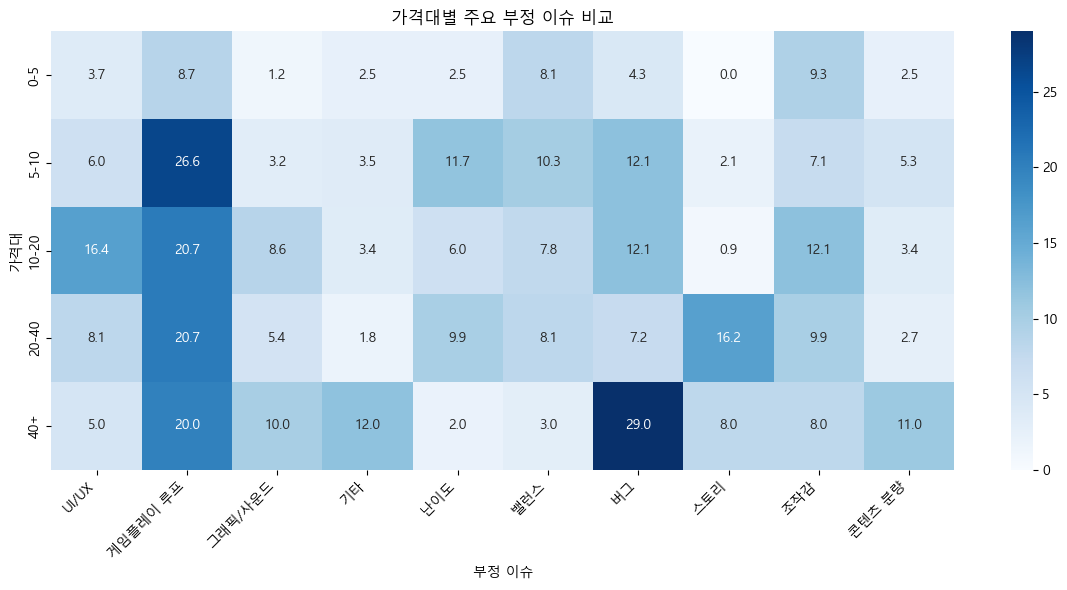

In [22]:
# ============================================================
# 12-1. 가격대별 주요 부정 이슈 히트맵
# ============================================================
# 값은 가격대별 리뷰 수 대비 부정 이슈 태그 비율이다.

price_review_count = (
    df_result
    .groupby("price_group")["recommendationid"]
    .nunique()
    .reindex(price_group_order)
)

price_negative = df_tag[
    (df_tag["tag_sentiment"] == "negative") &
    (df_tag["price_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

top_negative_issues = (
    price_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

price_negative_count = (
    price_negative[price_negative[issue_col].isin(top_negative_issues)]
    .groupby(["price_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

price_negative_pivot_count = (
    price_negative_count
    .pivot_table(
        index="price_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(price_group_order)
    .fillna(0)
)

price_negative_pivot_rate = price_negative_pivot_count.div(price_review_count, axis=0) * 100

print("[가격대별 주요 부정 이슈 비율(%)]")
display(price_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    price_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("가격대별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 결과 설명

이 히트맵은 가격대별로 어떤 부정 이슈가 상대적으로 자주 나타나는지 보여준다.  
값은 단순 태그 수가 아니라, 해당 가격대의 리뷰 수 대비 부정 이슈 태그 비율로 계산하였다.

이를 통해 출시 가격을 정할 때 단순히 유사 게임의 가격만 비교하지 않고, 해당 가격대에서 반복되는 불만 요인도 함께 고려할 수 있다.

# 13. Steam 태그별 이슈 비교

## 이 분석을 하는 이유

Steam 태그별 이슈 비교는 같은 Action 장르 안에서도 세부 게임 유형에 따라 유저가 중요하게 보는 요소가 달라지는지 확인하는 분석이다.

예를 들어 Roguelike 계열은 반복 플레이와 성장 구조가 중요할 수 있고, Survival 계열은 자원 관리와 콘텐츠 밀도가 중요할 수 있다.

## 한줄 결과 설명

Steam 태그별 긍정·부정 이슈를 비교하여, 태그 조합에 따른 출시 전 개발 우선순위를 구체화한다.

In [23]:
# ============================================================
# 13-0. Steam 태그별 게임 수 확인
# ============================================================
# 하나의 게임은 여러 Steam 태그를 동시에 가질 수 있다.
# 그래서 태그별 게임 수는 중복 포함될 수 있다.

steam_tag_game_count = (
    df_tag_for_steam_tag[["steam_tag", "appid"]]
    .drop_duplicates()
    .groupby("steam_tag")
    .agg(게임수=("appid", "nunique"))
    .sort_values("게임수", ascending=False)
    .head(10)
    .reset_index()
)

top_steam_tags = steam_tag_game_count["steam_tag"].tolist()

steam_tag_review_count = (
    df_tag_for_steam_tag[["steam_tag", "recommendationid"]]
    .drop_duplicates()
    .groupby("steam_tag")
    .size()
    .reindex(top_steam_tags)
)

print("[Steam 태그별 게임 수]")
display(steam_tag_game_count)

[Steam 태그별 게임 수]


,steam_tag,게임수
0,Action,17
1,2D,9
2,RPG,9
3,Adventure,7
4,Exploration,7
5,3D,7
6,First-Person,7
7,Controller,7
8,Puzzle,7
9,2D Platformer,6


[Steam 태그별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,0.3,1.6,1.4,7.9,3.8,1.1,4.4,0.8,0.5,1.9
2D,0.4,3.0,0.7,11.6,7.1,1.5,4.9,2.6,1.1,2.2
RPG,1.0,1.7,1.7,7.3,3.0,0.7,3.3,3.7,0.0,1.0
Adventure,0.8,2.5,0.0,4.2,3.3,0.8,1.7,1.7,0.0,0.0
Exploration,0.3,0.6,0.6,5.7,5.1,0.3,2.7,2.4,0.3,0.9
3D,1.1,1.1,1.1,9.7,7.5,0.0,3.2,1.6,1.6,1.6
First-Person,0.9,0.6,1.5,3.0,4.0,0.0,2.1,0.9,0.0,0.3
Controller,0.6,2.6,0.0,9.0,8.4,1.9,5.8,0.6,1.3,2.6
Puzzle,0.6,1.1,0.0,12.5,9.1,0.6,6.2,0.6,1.1,2.3


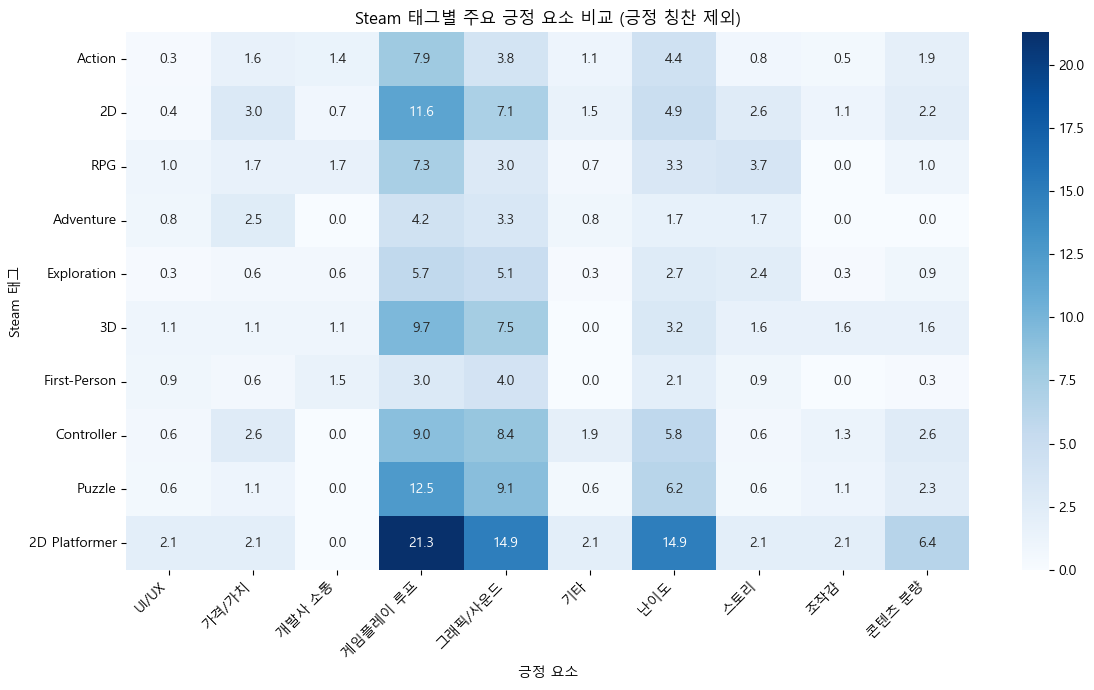

In [24]:
# ============================================================
# 13-1. Steam 태그별 주요 긍정 요소 히트맵
# ============================================================
# 긍정 요소는 '긍정 칭찬'을 제외하고 본다.
# 값은 Steam 태그별 리뷰 수 대비 긍정 이슈 태그 비율이다.

steam_positive = df_tag_for_steam_tag[
    (df_tag_for_steam_tag["tag_sentiment"] == "positive") &
    (df_tag_for_steam_tag["steam_tag"].isin(top_steam_tags)) &
    (df_tag_for_steam_tag[issue_col].notna())
].copy()

steam_positive = steam_positive[
    ~steam_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

top_positive_issues = (
    steam_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

steam_positive_count = (
    steam_positive[steam_positive[issue_col].isin(top_positive_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

steam_positive_pivot_count = (
    steam_positive_count
    .pivot_table(
        index="steam_tag",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(top_steam_tags)
    .fillna(0)
)

steam_positive_pivot_rate = steam_positive_pivot_count.div(steam_tag_review_count, axis=0) * 100

print("[Steam 태그별 주요 긍정 요소 비율(%)]")
display(steam_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("Steam 태그별 주요 긍정 요소 비교 (긍정 칭찬 제외)")
plt.xlabel("긍정 요소")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[Steam 태그별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,7.9,24.3,3.8,3.6,10.9,9.3,10.4,1.6,8.5,5.2
2D,6.0,15.0,4.1,2.2,6.0,7.9,4.1,6.7,9.0,2.6
RPG,10.3,20.9,8.0,6.0,5.6,6.0,14.6,9.0,10.0,5.6
Adventure,6.7,18.3,9.2,10.0,3.3,2.5,25.0,6.7,8.3,10.8
Exploration,6.2,22.0,6.5,5.7,8.0,4.8,16.1,9.5,9.5,4.5
3D,8.6,22.6,5.4,2.7,8.6,6.5,16.7,3.8,9.7,0.5
First-Person,8.2,26.4,6.7,5.5,10.9,8.2,20.1,4.6,7.6,6.1
Controller,6.5,23.9,6.5,3.9,11.0,4.5,11.0,3.9,7.7,0.6
Puzzle,5.1,18.8,4.0,2.8,8.5,3.4,12.5,3.4,9.7,0.6


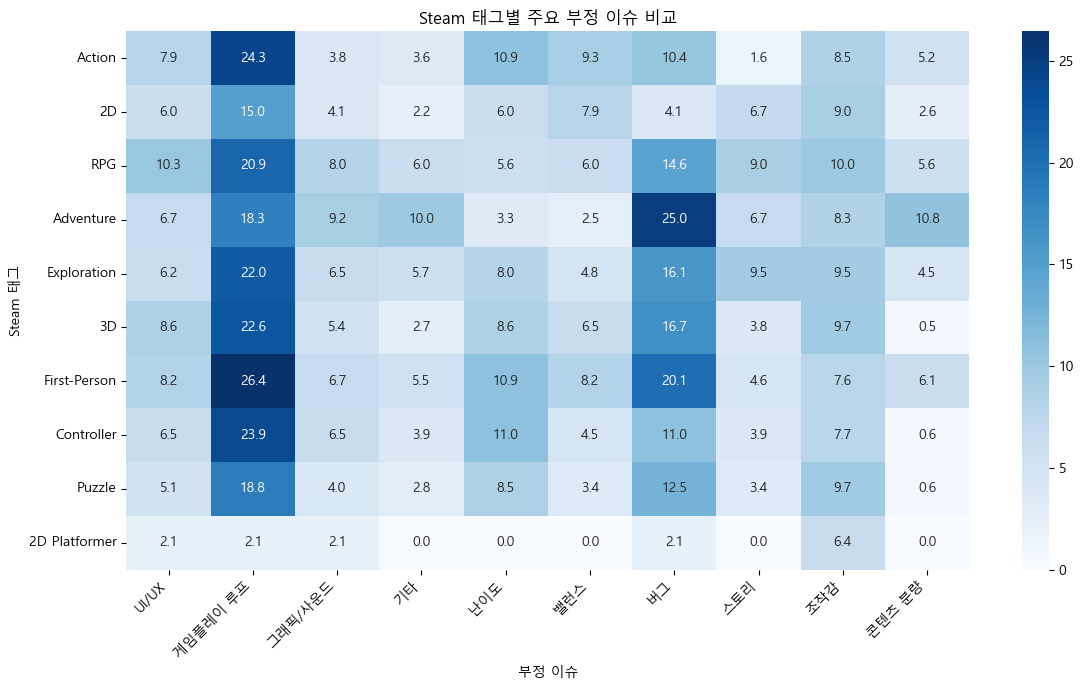

In [25]:
# ============================================================
# 13-2. Steam 태그별 주요 부정 이슈 히트맵
# ============================================================
# 값은 Steam 태그별 리뷰 수 대비 부정 이슈 태그 비율이다.

steam_negative = df_tag_for_steam_tag[
    (df_tag_for_steam_tag["tag_sentiment"] == "negative") &
    (df_tag_for_steam_tag["steam_tag"].isin(top_steam_tags)) &
    (df_tag_for_steam_tag[issue_col].notna())
].copy()

top_negative_issues = (
    steam_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

steam_negative_count = (
    steam_negative[steam_negative[issue_col].isin(top_negative_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

steam_negative_pivot_count = (
    steam_negative_count
    .pivot_table(
        index="steam_tag",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(top_steam_tags)
    .fillna(0)
)

steam_negative_pivot_rate = steam_negative_pivot_count.div(steam_tag_review_count, axis=0) * 100

print("[Steam 태그별 주요 부정 이슈 비율(%)]")
display(steam_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("Steam 태그별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 결과 설명

Steam 태그별 분석은 같은 Action 장르 안에서도 세부 유형에 따라 유저가 기대하는 요소가 달라지는지 확인하는 데 사용한다.

긍정 요소 분석에서는 전체 만족 표현에 가까운 `긍정 칭찬`을 제외하고, 실제 강점으로 볼 수 있는 요소만 비교하였다.  
부정 이슈 분석에서는 태그별 리뷰 수 대비 비율을 사용하여, 특정 태그에서 반복적으로 나타나는 리스크를 비교하였다.

# 14. 플레이 방식별 이슈 비교

## 이 분석을 하는 이유

플레이 방식별 이슈 비교는 싱글플레이, 멀티플레이, 협동 플레이 여부에 따라 유저가 중요하게 보는 요소가 달라지는지 확인하는 분석이다.

같은 Action 장르라도 싱글 중심 게임은 콘텐츠 분량, 난이도, 스토리 흐름이 중요할 수 있고, 멀티 또는 협동 요소가 있는 게임은 밸런스, 조작감, UI/UX, 기술 안정성이 더 중요하게 작용할 수 있다.

## 한줄 결과 설명

플레이 방식별 이슈를 비교하여, 싱글/멀티/협동 여부에 맞춘 출시 전 QA 기준을 정리한다.

In [26]:
# ============================================================
# 14-0. 플레이 방식별 게임 수 확인
# ============================================================
# 플레이 방식별로 몇 개의 게임이 포함되어 있는지 확인한다.

play_mode_game_count = (
    df_result
    .drop_duplicates(["appid", "play_mode_group"])
    .groupby("play_mode_group")
    .agg(게임수=("appid", "nunique"))
    .reindex(play_mode_order)
    .reset_index()
)

play_mode_review_count = (
    df_result
    .groupby("play_mode_group")["recommendationid"]
    .nunique()
    .reindex(play_mode_order)
)

print("[플레이 방식별 게임 수]")
display(play_mode_game_count)

[플레이 방식별 게임 수]


,play_mode_group,게임수
0,싱글 중심,19.0
1,멀티 포함,1.0
2,협동 포함,8.0
3,기타/미확인,NaN


[플레이 방식별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
play_mode_group,,,,,,,,,,
싱글 중심,0.7,1.7,0.8,8.9,6.1,0.3,2.7,1.9,0.8,1.9
멀티 포함,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
협동 포함,0.0,1.1,2.3,6.9,0.6,1.7,5.7,1.1,0.6,0.6
기타/미확인,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


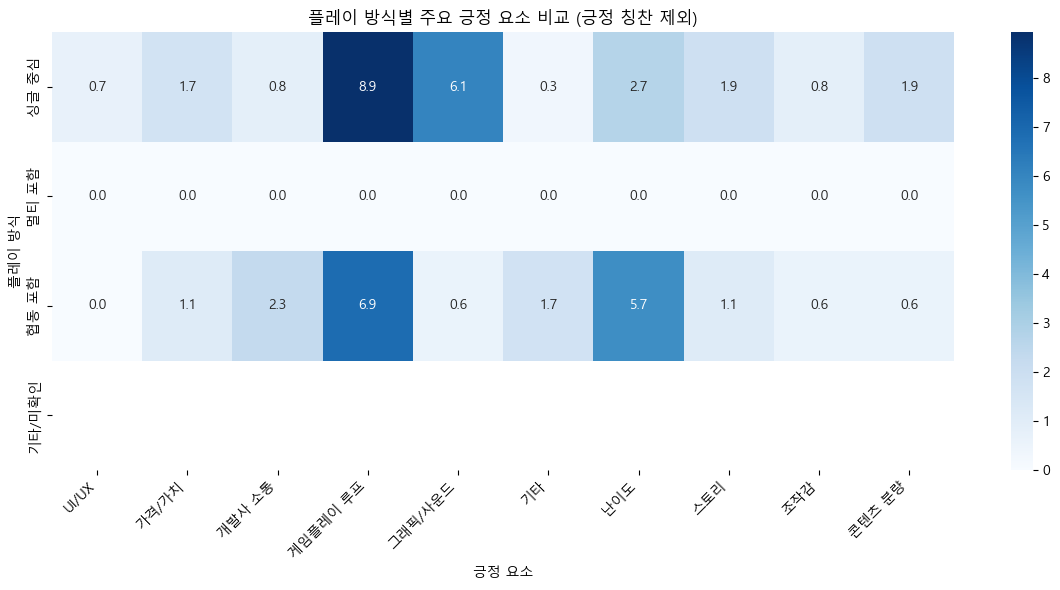

In [27]:
# ============================================================
# 14-1. 플레이 방식별 주요 긍정 요소 히트맵
# ============================================================
# 긍정 요소는 '긍정 칭찬'을 제외하고 본다.
# 값은 플레이 방식별 리뷰 수 대비 긍정 이슈 태그 비율이다.

play_positive = df_tag[
    (df_tag["tag_sentiment"] == "positive") &
    (df_tag["play_mode_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

play_positive = play_positive[
    ~play_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

top_positive_issues = (
    play_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

play_positive_count = (
    play_positive[play_positive[issue_col].isin(top_positive_issues)]
    .groupby(["play_mode_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

play_positive_pivot_count = (
    play_positive_count
    .pivot_table(
        index="play_mode_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(play_mode_order)
    .fillna(0)
)

play_positive_pivot_rate = play_positive_pivot_count.div(play_mode_review_count, axis=0) * 100

print("[플레이 방식별 주요 긍정 요소 비율(%)]")
display(play_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    play_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("플레이 방식별 주요 긍정 요소 비교 (긍정 칭찬 제외)")
plt.xlabel("긍정 요소")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[플레이 방식별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
play_mode_group,,,,,,,,,,
싱글 중심,6.4,19.6,4.9,4.6,5.6,7.8,12.6,5.6,7.9,4.6
멀티 포함,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
협동 포함,10.3,22.9,4.6,2.9,13.7,8.6,9.7,0.0,12.0,5.7
기타/미확인,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


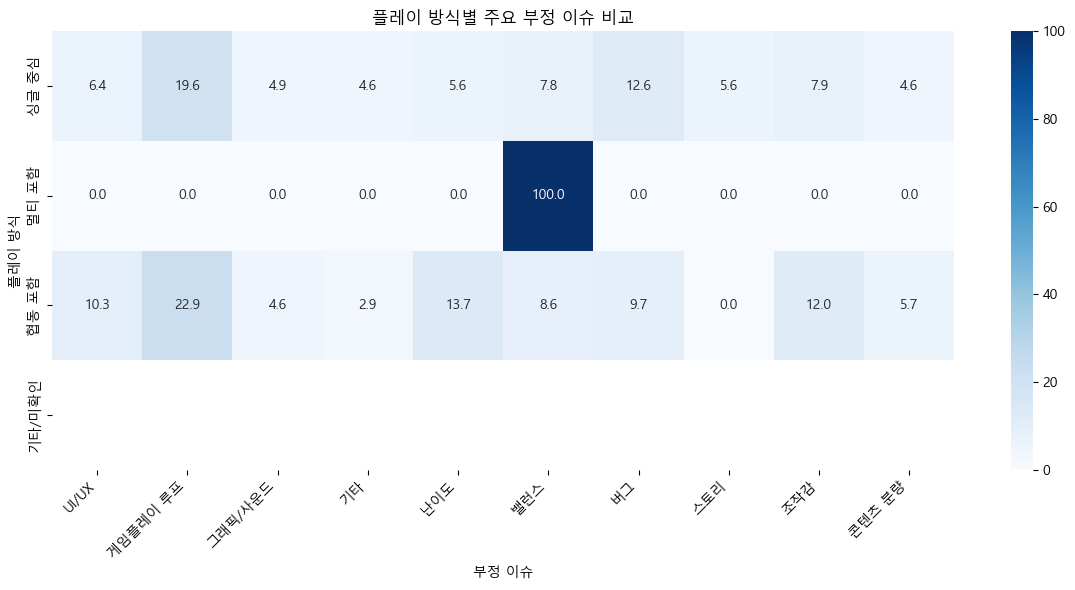

In [28]:
# ============================================================
# 14-2. 플레이 방식별 주요 부정 이슈 히트맵
# ============================================================
# 값은 플레이 방식별 리뷰 수 대비 부정 이슈 태그 비율이다.

play_negative = df_tag[
    (df_tag["tag_sentiment"] == "negative") &
    (df_tag["play_mode_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

top_negative_issues = (
    play_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

play_negative_count = (
    play_negative[play_negative[issue_col].isin(top_negative_issues)]
    .groupby(["play_mode_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

play_negative_pivot_count = (
    play_negative_count
    .pivot_table(
        index="play_mode_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(play_mode_order)
    .fillna(0)
)

play_negative_pivot_rate = play_negative_pivot_count.div(play_mode_review_count, axis=0) * 100

print("[플레이 방식별 주요 부정 이슈 비율(%)]")
display(play_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    play_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("플레이 방식별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 결과 설명

플레이 방식별 분석은 출시 전 체크리스트를 더 세분화하기 위한 분석이다.

싱글 중심 게임은 콘텐츠 밀도, 난이도, 반복 플레이 경험을 더 중점적으로 볼 수 있다.  
멀티 또는 협동 요소가 있는 게임은 밸런스, 조작감, UI/UX, 기술 안정성을 더 세밀하게 점검해야 한다.

# 15. 출시 전 점검 항목 도출

## 이 분석을 하는 이유

LLM 분석 결과를 실제 개발 의사결정에 활용하려면, 반복적으로 나타난 이슈를 점검 항목으로 바꿔야 한다.

## 한줄 결과 설명

반복 이슈를 출시 전 체크리스트로 정리하여 개발 우선순위와 QA 기준으로 연결한다.

| 점검 영역 | 점검 질문 | 관련 이슈 | 권장 대응 |
|---|---|---|---|
| 핵심 플레이 루프 | 전투, 이동, 반복 플레이 구조가 짧은 시간 안에도 재미있게 전달되는가? | 게임플레이 루프 | 프로토타입/데모 단계에서 핵심 루프 반복 테스트를 우선 진행 |
| 조작감 | 입력 반응, 카메라, 이동 방식, 키 설정이 불편하지 않은가? | 조작감 | 조작 튜토리얼, 키 리바인딩, 카메라 옵션, 피드백 효과 점검 |
| UI/UX와 초반 안내 | 초반 목표, 메뉴, 인벤토리, 튜토리얼이 직관적으로 안내되는가? | UI/UX | 첫 10~30분 플레이 구간에서 목표 안내와 메뉴 접근성 테스트 |
| 난이도와 밸런스 | 초반 난이도가 과도하거나, 특정 구간에서 불합리하게 느껴지지 않는가? | 난이도, 밸런스 | 난이도 곡선과 실패 후 재도전 경험 점검 |
| 버그와 기술 안정성 | 진행 불가, 저장 오류, 크래시, 성능 저하 문제가 없는가? | 버그, 크래시, 저장/진행, 성능, 최적화 | 출시 직전 QA에서 진행 불가/크래시/저장 문제를 우선 점검 |
| 콘텐츠 밀도와 반복 피로도 | 출시 초기에 충분한 콘텐츠와 반복 플레이 동기가 있는가? | 콘텐츠 분량, 성장/반복 노가다 | 반복 플레이 동기, 보상 구조, 콘텐츠 소모 속도 점검 |
| 그래픽/사운드와 분위기 | 타격감, 사운드, 분위기, 시각적 피드백이 장르 기대치에 맞는가? | 그래픽/사운드 | 액션 피드백, 효과음, 분위기 연출을 데모 반응으로 검증 |
| 가격 대비 가치 | 가격대에 비해 제공되는 콘텐츠와 완성도가 납득 가능한가? | 가격/가치, 콘텐츠 분량 | 유사 게임 가격대와 콘텐츠 분량을 함께 비교해 출시 가격 검토 |

# 16. 핵심 인사이트

## 인사이트 1. Action 장르 유저는 핵심 플레이 루프를 가장 중요하게 평가한다

게임플레이 루프는 긍정과 부정 양쪽에서 모두 강하게 나타나는 평가 축이다.  
전투, 이동, 반복 플레이 구조가 잘 전달되면 강점이 되지만, 단조롭거나 불편하면 부정 리뷰로 이어질 수 있다.

## 인사이트 2. 조작감, UI/UX, 난이도는 출시 초기 부정 반응의 주요 리스크다

Action 장르는 조작과 피드백을 바로 체감하는 장르이기 때문에, 초반 조작 안내와 UI, 난이도 곡선을 출시 전 단계에서 점검해야 한다.

## 인사이트 3. 가격대별 분석은 가격 대비 기대치를 점검하는 데 활용할 수 있다

가격대별 주요 부정 이슈를 보면, 특정 가격대에서 유저가 기대하는 콘텐츠 밀도와 완성도 기준을 확인할 수 있다.

## 인사이트 4. Steam 태그별 분석은 세부 게임 유형별 리스크를 나누는 데 도움이 된다

같은 Action 장르라도 Roguelike, RPG, Survival, Co-op 같은 태그에 따라 유저가 기대하는 경험은 달라질 수 있다.

## 인사이트 5. 플레이 방식별 분석은 QA 체크리스트를 세분화하는 데 유용하다

싱글 중심 게임과 협동/멀티 요소가 있는 게임은 점검해야 할 리스크가 다를 수 있다.  
따라서 출시 전 체크리스트는 플레이 방식에 따라 세분화하는 것이 좋다.

# 17. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 Action 장르 게임 전체가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 시장의 절대값이 아니라 표본 안에서 확인된 경향으로 해석해야 한다.

또한 이번 결과는 v2 분석 기준이다.  
리뷰 수를 더 늘리면 표본 수는 증가하지만, 리뷰 수가 많은 일부 게임에 결과가 과도하게 몰릴 수 있다.  
따라서 본 보고서에서는 장르 전체 경향을 해석하기 위해 v2 결과를 사용하였다.

마지막으로 LLM이 생성한 `urgency`, `summary`, `suggested_action`, `issue_tags`는 리뷰 문맥을 기반으로 한 해석 결과다.  
따라서 실제 장애 지표나 정답 라벨이 아니라, 출시 전 점검을 돕는 참고 자료로 활용하는 것이 적절하다.

## 최종 정리

이번 출시 전 분석은 Action 장르 유사 게임의 D0-D30 초기 리뷰를 LLM으로 분석하여, 유저가 긍정적으로 평가한 요소와 불만을 가진 요소를 정리하였다.

기본 분석에서는 장르 공통의 긍정/부정 요소를 확인했고, 확장 분석에서는 가격대, Steam 태그, 플레이 방식에 따라 반복 이슈가 어떻게 달라지는지 확인하였다.

최종적으로 이 결과는 Action 장르 게임을 출시하기 전, 핵심 플레이 루프, 조작감, UI/UX, 난이도, 밸런스, 기술 안정성, 콘텐츠 밀도, 가격 대비 가치를 점검하는 체크리스트로 활용할 수 있다.

# 부록. 보고서 작성용 핵심 값 확인

아래 셀은 팀 노션이나 최종 보고서에 문장을 작성하기 전에 확인하는 요약 자료다.

In [29]:
# ============================================================
# 부록. 보고서 작성용 핵심 값 확인
# ============================================================
# 보고서에 넣을 핵심 숫자를 한 번에 확인한다.

report_values = pd.DataFrame({
    "항목": [
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 긍정 리뷰 수",
        "LLM 부정 리뷰 수",
        "LLM 혼합 리뷰 수",
        "High urgency 리뷰 수",
        "Steam-LLM exact_match 수",
        "Steam-LLM partial_match 수",
        "이슈 태그 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        (df_result["llm_sentiment"] == "positive").sum(),
        (df_result["llm_sentiment"] == "negative").sum(),
        (df_result["llm_sentiment"] == "mixed").sum(),
        (df_result["urgency"] == "high").sum(),
        (df_result["sentiment_relation"] == "exact_match").sum(),
        (df_result["sentiment_relation"] == "partial_match").sum(),
        len(df_tag),
        len(set(df_result["recommendationid"]) - set(df_tag["recommendationid"])),
    ]
})

display(report_values)

,항목,값
0,최종 분석 리뷰 수,770
1,최종 분석 게임 수,28
2,Steam 긍정 리뷰 수,511
3,Steam 부정 리뷰 수,259
4,LLM 긍정 리뷰 수,465
5,LLM 부정 리뷰 수,241
6,LLM 혼합 리뷰 수,58
7,High urgency 리뷰 수,214
8,Steam-LLM exact_match 수,704
9,Steam-LLM partial_match 수,58
